## Overview

Objective: One-paragraph summary of what the model is solving.

Dataset: Short description (size, main features, target classes, any preprocessing summary).

Evaluation goal: e.g. “We evaluate models on the held-out test set using precision, recall, and F1.”


How we choose the best model

## Best Model Summary

Model type (e.g., Neural Network, Random Forest, XGBoost).

Hyperparameters and how it was selected (brief reference to tuning, not all details).

Training/validation performance summary (table with mean ± std from CV).



in this case we select our best model according to the best F1.


In [1]:
# get best model

import mlflow
import pandas as pd

import mlflow

#mlflow.set_tracking_uri("sqlite:///../mlflow.db")
#mlflow.set_tracking_uri("sqlite:////home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/mlflow.db")


mlflow.set_tracking_uri("sqlite:///../mlflow.db")





2025/11/05 20:20:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/05 20:20:40 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.f1,metrics.accuracy,metrics.precision,metrics.recall,...,params.early_stop,params.val_size,params.val_shape,tags.mlflow.user,tags.mlflow.source.type,tags.data_version,tags.mlflow.source.name,tags.mlflow.source.git.commit,tags.mlflow.runName,tags.model_type
0,720cd98dc8b74be3925a271ef9cd187e,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-05 23:13:55.168000+00:00,2025-11-05 23:13:59.712000+00:00,0.955539,0.949745,0.966571,0.949745,...,-1,0.2,"(15461, 78)",marcos,LOCAL,v1,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,4bbd988ca3bc119ed294572010c85e95e5d6f5ad,Tuning,nn


In [3]:
df1 = mlflow.search_runs(experiment_names=["network_security"]) #network_security

df1

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.f1,metrics.accuracy,metrics.precision,metrics.recall,...,params.early_stop,tags.mlflow.user,tags.tuning_run_id,tags.mlflow.source.name,tags.mlflow.source.git.commit,tags.dataset,tags.mlflow.source.type,tags.data_version,tags.mlflow.runName,tags.model_type
0,f253f9bdd7ed4d19a75efbe0ee08c613,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-05 23:23:32.335000+00:00,2025-11-05 23:23:33.285000+00:00,0.990006,0.985420,0.995754,0.985420,...,None,marcos,b5b1c2c5d0f540d7b2a3583843645938,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,4bbd988ca3bc119ed294572010c85e95e5d6f5ad,test,LOCAL,v1,test_evaluation,None
1,b5b1c2c5d0f540d7b2a3583843645938,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-05 23:21:29.406000+00:00,2025-11-05 23:21:32.888000+00:00,0.989398,0.984542,0.995493,0.984542,...,None,marcos,None,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,4bbd988ca3bc119ed294572010c85e95e5d6f5ad,None,LOCAL,v1,Tuning,tree
2,720cd98dc8b74be3925a271ef9cd187e,1,FINISHED,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,2025-11-05 23:13:55.168000+00:00,2025-11-05 23:13:59.712000+00:00,0.955539,0.949745,0.966571,0.949745,...,-1,marcos,None,/home/marcos/Escritorio/AI-prod/AI-Driven-Netw...,4bbd988ca3bc119ed294572010c85e95e5d6f5ad,None,LOCAL,v1,Tuning,nn


In [95]:
from mlflow.tracking import MlflowClient

In [96]:
def select_best_model(experiment_name, metric="f1", model_type=None, data_version="v1"):
    client = MlflowClient()
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment is None:
        raise ValueError(f"Experiment '{experiment_name}' not found.")

    # Build filter
    filter_str = f"run_name = 'Tuning' AND tags.data_version = '{data_version}'"
    if model_type:
        filter_str += f" AND tags.model_type = '{model_type}'"

    # Search runs
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=filter_str,
        order_by=[f"metrics.{metric} DESC"],
    )

    if not runs:
        raise ValueError(f"No runs found for model_type='{model_type}' and data_version='{data_version}'.")

    # Take best run
    best_run = runs[0]
    run_id = best_run.info.run_id
    
    return best_run

In [97]:
br = select_best_model("network_security")

In [98]:
br

<Run: data=<RunData: metrics={'accuracy': 0.9718646918051872,
 'f1': 0.9813377730506281,
 'precision': 0.9938563569872373,
 'recall': 0.9718646918051872}, params={'balance_factor': '0.2',
 'criterion': 'gini',
 'max_depth': '8',
 'min_samples_split': '3',
 'train_shape': '(150434, 78)',
 'val_shape': '(15461, 78)',
 'val_size': '0.2'}, tags={'data_version': 'v1',
 'mlflow.runName': 'Tuning',
 'mlflow.source.git.commit': '4bbd988ca3bc119ed294572010c85e95e5d6f5ad',
 'mlflow.source.name': '/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/scripts/tuning.py',
 'mlflow.source.type': 'LOCAL',
 'mlflow.user': 'marcos',
 'model_type': 'tree'}>, info=<RunInfo: artifact_uri='/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/mlruns/1/6ee1c5333f99461e91e868ae4934ebc9/artifacts', end_time=1762381314373, experiment_id='1', lifecycle_stage='active', run_id='6ee1c5333f99461e91e868ae4934ebc9', run_name='Tuning', start_time=1762381310736, status='FINISHED', user_id='marcos'>, inputs=<R

In [99]:
run = br

# Get metrics and params
metrics = run.data.metrics
params = run.data.params

# Or convert to DataFrame for easier handling
import pandas as pd

df = pd.DataFrame({
    "metric": list(metrics.keys()),
    "value": list(metrics.values())
})

df_params = pd.DataFrame({
    "param": list(params.keys()),
    "value": list(params.values())
})


In [100]:
df

,metric,value
0,accuracy,0.971865
1,precision,0.993856
2,recall,0.971865
3,f1,0.981338


In [101]:
df_params

,param,value
0,balance_factor,0.2
1,val_size,0.2
2,train_shape,"(150434, 78)"
3,val_shape,"(15461, 78)"
4,criterion,gini
5,max_depth,8
6,min_samples_split,3


In [102]:
run.data.tags['model_type']

'tree'

In [103]:
br.info.run_id

'6ee1c5333f99461e91e868ae4934ebc9'

📊 3. Test Results

Test metrics (precision, recall, F1, accuracy, AUC, etc.).

Confusion matrix (nice visualization).

Classification report table.

Optional: ROC/PR curves (especially useful for imbalanced problems).

Highlight the most common errors or confusions if relevant.

In [110]:
def get_test_data(experiment_name, tuning_run_id, data_version="v1"):
    client = MlflowClient()
    experiment = client.get_experiment_by_name(experiment_name)
    
    if experiment is None:
        raise ValueError(f"Experiment '{experiment_name}' not found.")

    # Build filter
    filter_str = f"run_name = 'test_evaluation' AND tags.data_version = '{data_version}'"
    filter_str += f" AND tags.tuning_run_id = '{tuning_run_id}'"

    # Search runs
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=filter_str,
    )

    if not runs:
        raise ValueError(f"No runs found")

    # return
    return runs[0]

In [111]:
r = get_test_data('network_security',br.info.run_id)

In [112]:
r

<Run: data=<RunData: metrics={'accuracy': 0.9671441039067714,
 'f1': 0.9782965101243766,
 'precision': 0.9928769205765617,
 'recall': 0.9671441039067714}, params={'model_type': 'tree'}, tags={'data_version': 'v1',
 'dataset': 'test',
 'mlflow.runName': 'test_evaluation',
 'mlflow.source.git.commit': '4bbd988ca3bc119ed294572010c85e95e5d6f5ad',
 'mlflow.source.name': '/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/scripts/evaluation.py',
 'mlflow.source.type': 'LOCAL',
 'mlflow.user': 'marcos',
 'tuning_run_id': '6ee1c5333f99461e91e868ae4934ebc9'}>, info=<RunInfo: artifact_uri='/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/mlruns/1/7d964ffb1b2c4484836c607cc4e8e275/artifacts', end_time=1762382550922, experiment_id='1', lifecycle_stage='active', run_id='7d964ffb1b2c4484836c607cc4e8e275', run_name='test_evaluation', start_time=1762382549998, status='FINISHED', user_id='marcos'>, inputs=<RunInputs: dataset_inputs=[], model_inputs=[]>, outputs=None>

In [113]:
# metrics

r.data.metrics

{'accuracy': 0.9671441039067714,
 'precision': 0.9928769205765617,
 'recall': 0.9671441039067714,
 'f1': 0.9782965101243766}

In [114]:
artifact_uri = run.info.artifact_uri
print(artifact_uri)


/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/mlruns/1/6ee1c5333f99461e91e868ae4934ebc9/artifacts


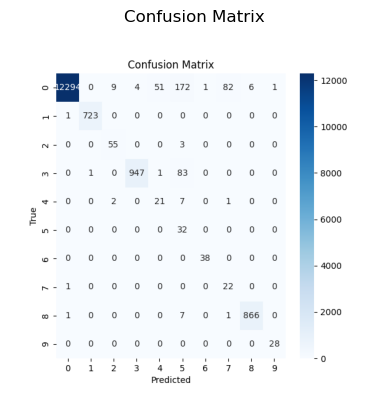

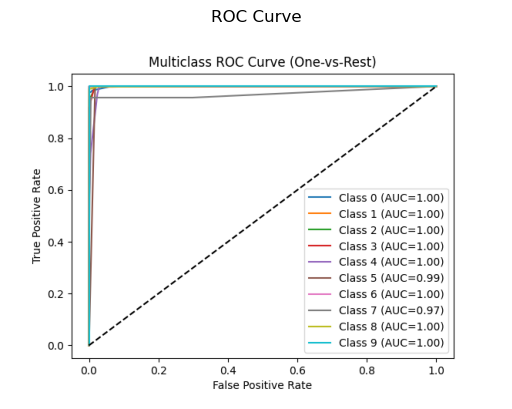

In [116]:
import matplotlib.pyplot as plt
from PIL import Image
import os

cm_path = os.path.join(artifact_uri, "confusion_matrix.png")
roc_path = os.path.join(artifact_uri, "roc_multiclass.png")

# Confusion matrix
img_cm = Image.open(cm_path)
plt.imshow(img_cm)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

# ROC curve
img_roc = Image.open(roc_path)
plt.imshow(img_roc)
plt.axis("off")
plt.title("ROC Curve")
plt.show()


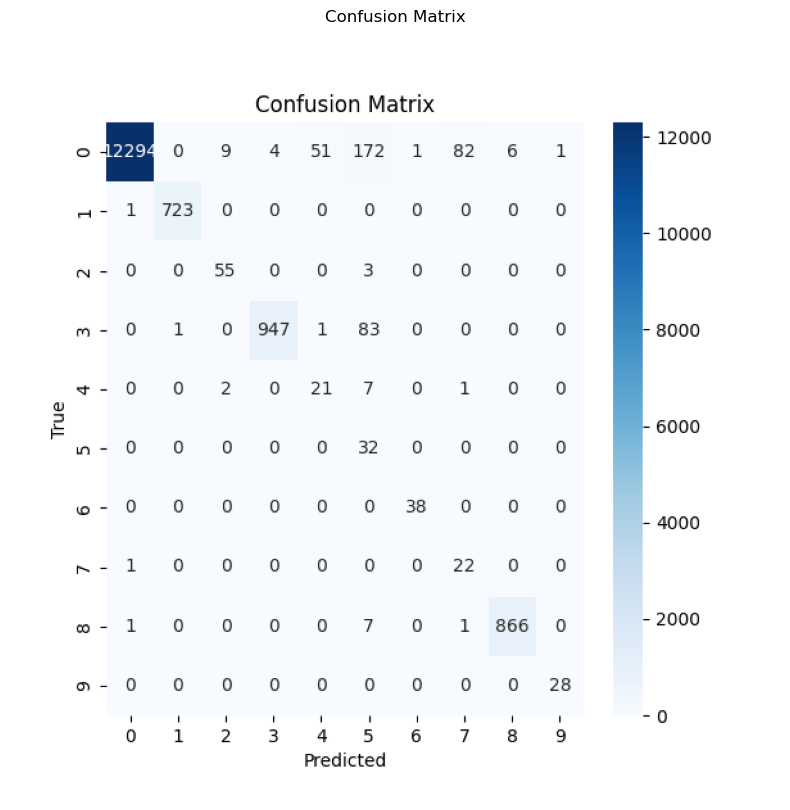

In [118]:
# Confusion matrix
img_cm = Image.open(cm_path)
plt.figure(figsize=(12, 10))  # bigger display
plt.imshow(img_cm)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
Conclusion or final thoughts

Test set evaluation

Plots for final model(s) performance

Tables and visualizations for reports or presentations

Can include inference examples




1️⃣ Report best per model type

Even if you ultimately pick one “best” model overall, it’s useful to keep track of the top performer in each family:

Model Type	Best Hyperparams	Metrics	Notes
NN	…	…	High accuracy, slower
Decision Tree	…	…	Slightly lower accuracy, very interpretable
Random Forest	…	…	High accuracy, medium interpretability

This lets you:

Compare across model families.

Justify choices for interpretability, speed, or memory.

Keep a record in MLflow or a notebook.

2️⃣ Include subjective criteria

If some quantities are not purely measurable (like interpretability, explainability, or deployment constraints), you can:

Add a column for “qualitative score”.

Document why a slightly worse metric may be acceptable (e.g., chose a tree for interpretability).

3️⃣ Notebook workflow

Use experiment_dashboard.ipynb to pull MLflow metrics.

Compare the best per model type and the overall best.

Include visualizations like:

Feature importances

Confusion matrices

ROC/PR curves (if relevant)

Add a short rationale for model choice, including subjective factors.

✅ Key principle

Objective metrics = primary filter.

Subjective criteria (interpretability, memory, deployment constraints) = secondary filter.

This approach makes your reporting transparent and reproducible, even if the final pick is not purely the highest metric.

In [1]:
"""

feature importance for trees

import matplotlib.pyplot as plt
import pandas as pd

# Suppose 'model' is your trained tree/random forest model
# and 'feature_names' is a list of column names
feature_importances = model.feature_importances_
feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values("importance", ascending=False)

# Plot
plt.figure(figsize=(8,6))
plt.barh(feat_df["feature"], feat_df["importance"], color="skyblue")
plt.gca().invert_yaxis()  # largest on top
plt.xlabel("Importance")
plt.title("Feature Importances")
plt.show()
"""

'\n\nfeature importance for trees\n\nimport matplotlib.pyplot as plt\nimport pandas as pd\n\n# Suppose \'model\' is your trained tree/random forest model\n# and \'feature_names\' is a list of column names\nfeature_importances = model.feature_importances_\nfeat_df = pd.DataFrame({\n    "feature": feature_names,\n    "importance": feature_importances\n}).sort_values("importance", ascending=False)\n\n# Plot\nplt.figure(figsize=(8,6))\nplt.barh(feat_df["feature"], feat_df["importance"], color="skyblue")\nplt.gca().invert_yaxis()  # largest on top\nplt.xlabel("Importance")\nplt.title("Feature Importances")\nplt.show()\n'

Notes:

For NNs, feature importance is less straightforward; you could use:

Permutation importance

SHAP values

Integrated gradients (for deep models)

For a quick overview, tree-based importances are usually enough.

If you want, I can draft a generic notebook snippet that:

Pulls the best model per type from MLflow

Shows feature importance plots for tree models

And optionally SHAP plots for NN models